# Reconhecimento de Gestos Touch com TensorFlow Lite Micro
Este notebook gerencia o fluxo completo de engenharia de recursos, treinamento, quantização pós-treinamento (PTQ) e validação de modelos de Deep Learning otimizados para sistemas embarcados (ESP32).

### Etapas do Desenvolvimento:
- Configuração do ambiente de execução e dependências
- Extração de características estatísticas de sinais brutos de sensores capacitivos
- Treinamento da rede neural densa (Multilayer Perceptron)
- Avaliação de desempenho do modelo em precisão simples (Float32)
- Quantização inteira de 8 bits (INT8) focada em microcontroladores
- Análise comparativa de métricas e tamanho físico dos modelos binários

In [1]:
!pip -q install tensorflow absl-py matplotlib

## 1) Extração de Características e Funções de Treinamento
Construção do pipeline para transformar a janela de sinais brutos (80 amostras por linha) em vetores estatísticos mais eficientes para o aprendizado da rede neural.

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from absl import logging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

NUM_CLASSES = 4

def extract_features_from_row(row_data):
    s1 = row_data[0::2]
    s2 = row_data[1::2]
    
    s1_min = np.min(s1)
    s1_mean = np.mean(s1)
    s1_std = np.std(s1)
    s1_diff = s1[-1] - s1[0]
    
    s2_min = np.min(s2)
    s2_mean = np.mean(s2)
    s2_std = np.std(s2)
    s2_diff = s2[-1] - s2[0]
    
    return np.array([
        s1_min, s1_mean, s1_std, s1_diff,
        s2_min, s2_mean, s2_std, s2_diff
    ], dtype=np.float32)

def get_data(csv_path="dataset.csv"):
    df = pd.read_csv(csv_path, header=None)
    
    y_values = df.iloc[:, 0].values.astype(np.int32)
    raw_x_values = df.iloc[:, 1:].values.astype(np.float32)
    
    print("Processando e extraindo características das séries temporais...")
    x_features = np.array([extract_features_from_row(row) for row in raw_x_values])
    
    scaler = StandardScaler()
    x_values = scaler.fit_transform(x_features)
    
    print("Formato dos dados brutos:", raw_x_values.shape)
    print("Formato após engenharia de atributos:", x_values.shape)
    print("Formato das classes (labels):", y_values.shape)
    
    return x_values, y_values, scaler

def create_model(input_shape) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_shape,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def convert_tflite_model(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def save_tflite_model(tflite_model, save_dir, model_name):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    save_path = os.path.join(save_dir, model_name)
    with open(save_path, "wb") as f:
        f.write(tflite_model)
        
    logging.info("Modelo TFLite salvo com sucesso em: %s", save_path)

def train_model(epochs, x_values, y_values):
    x_train, x_test, y_train, y_test = train_test_split(
        x_values,
        y_values,
        test_size=0.2,
        random_state=42,
        stratify=y_values
    )
    
    model = create_model(x_train.shape[1])
    model.summary()
    
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        validation_data=(x_test, y_test),
        batch_size=16,
        verbose=2,
        shuffle=True
    )
    
    loss, acc = model.evaluate(x_test, y_test)
    print("\nAcurácia obtida no conjunto de testes:", acc)
    return model, history

def train(csv_path="dataset.csv", epochs=100, save_dir="gesture_models"):
    x_values, y_values, scaler = get_data(csv_path)
    trained_model, history = train_model(epochs, x_values, y_values)
    
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
    tflite_model = convert_tflite_model(trained_model)
    
    save_tflite_model(
        tflite_model,
        save_dir,
        model_name="gesture_model.tflite"
    )
    
    print("\nExecução do pipeline finalizada.")
    return trained_model

### Inicialização do Treinamento
Configuração dos hiperparâmetros e execução da rotina principal para geração do modelo de referência em ponto flutuante.

In [3]:
EPOCHS = 100
SAVE_DIR = "gesture_models"
DATASET_PATH = "dataset.csv"

trained_model = train(
    csv_path=DATASET_PATH,
    epochs=EPOCHS,
    save_dir=SAVE_DIR
)

Processando e extraindo características das séries temporais...
Formato dos dados brutos: (200, 80)
Formato após engenharia de atributos: (200, 8)
Formato das classes (labels): (200,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 884 (3.45 KB)

 Trainable params: 884 (3.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 - 4s - 440ms/step - accuracy: 0.2375 - loss: 1.6015 - val_accuracy: 0.2500 - val_loss: 1.4770
Epoch 2/100
10/10 - 2s - 178ms/step - accuracy: 0.2313 - loss: 1.4460 - val_accuracy: 0.3250 - val_loss: 1.3410
Epoch 3/100
10/10 - 0s - 11ms/step - accuracy: 0.2812 - loss: 1.3468 - val_accuracy: 0.4500 - val_loss: 1.2212
Epoch 4/100
10/10 - 0s - 11ms/step - accuracy: 0.4000 - loss: 1.2234 - val_accuracy: 0.5000 - val_loss: 1.1250
Epoch 5/100
10/10 - 0s - 11ms/step - accuracy: 0.5375 - loss: 1.1234 - val_accuracy: 0.7500 - val_loss: 1.0404
Epoch 6/100
10/10 - 0s - 11ms/step - accuracy: 0.6313 - loss: 1.0894 - val_accuracy: 0.7500 - val_loss: 0.9701
Epoch 7/100
10/10 - 0s - 11ms/step - accuracy: 0.6812 - loss: 1.0164 - val_accuracy: 0.7000 - val_loss: 0.9079
Epoch 8/100
10/10 - 0s - 11ms/step - accuracy: 0.6562 - loss: 0.9520 - val_accuracy: 0.7000 - val_loss: 0.8489
Epoch 9/100
10/10 - 0s - 11ms/step - accuracy: 0.7063 - loss: 0.9020 - val_accuracy: 0.7500 - val_loss: 0.7926

## 2) Rotinas de Validação da Inferência
Mapeamento de funções auxiliares para simular a inferência embarcada no Python. Caso o runtime local do TensorFlow Lite Micro não esteja disponível, o script utiliza automaticamente o interpretador convencional para fins de validação.

In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from absl import logging
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

runtime = None
try:
    from tflite_micro.python.tflite_micro import runtime
except ImportError:
    logging.warning("Interpretador tflite_micro indisponível. Alternando para o TF Lite padrão.")

OpResolverType = None
try:
    import ai_edge_litert.interpreter as tflite_interp
    try:
        from ai_edge_litert.interpreter import OpResolverType
    except ImportError:
        OpResolverType = None
except ImportError:
    try:
        import tflite_runtime.interpreter as tflite_interp
        try:
            from tflite_runtime.interpreter import OpResolverType
        except ImportError:
            OpResolverType = None
    except ImportError:
        import tensorflow.lite as tflite_interp

CLASS_NAMES = ["no_touch", "one_touch", "two_touch", "hold_touch"]

def extract_features_from_row(row_data):
    s1 = row_data[0::2]
    s2 = row_data[1::2]
    
    s1_min = np.min(s1)
    s1_mean = np.mean(s1)
    s1_std = np.std(s1)
    s1_diff = s1[-1] - s1[0]
    
    s2_min = np.min(s2)
    s2_mean = np.mean(s2)
    s2_std = np.std(s2)
    s2_diff = s2[-1] - s2[0]
    
    return np.array([
        s1_min, s1_mean, s1_std, s1_diff,
        s2_min, s2_mean, s2_std, s2_diff
    ], dtype=np.float32)

def load_dataset(csv_path="dataset.csv"):
    df = pd.read_csv(csv_path, header=None)
    y_values = df.iloc[:, 0].values.astype(np.int32)
    raw_x_values = df.iloc[:, 1:].values.astype(np.float32)
    
    print("Processando dados brutos do arquivo de validação...")
    x_features = np.array([extract_features_from_row(row) for row in raw_x_values])
    return x_features, y_values

def prepare_quantized_input(x_value, input_shape, input_details):
    input_data = np.reshape(x_value, input_shape)
    quantization = input_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization
    
    if input_details["dtype"] in (np.int8, np.uint8) and scale != 0:
        quantized = np.round(input_data / scale + zero_point)
        dtype_info = np.iinfo(input_details["dtype"])
        quantized = np.clip(quantized, dtype_info.min, dtype_info.max)
        return quantized.astype(input_details["dtype"])
    return input_data.astype(input_details["dtype"])

def dequantize_output(output_tensor, output_details):
    quantization = output_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization
    
    if output_details["dtype"] in (np.int8, np.uint8) and scale != 0:
        return (output_tensor.astype(np.float32) - zero_point) * scale
    return output_tensor.astype(np.float32)

def predict_tflite(model_path, x_values):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_shape = input_details["shape"]
    
    quantization = input_details.get("quantization", (0.0, 0))
    scale, zero_point = quantization
    is_quantized = input_details["dtype"] in [np.int8, np.uint8]
    
    predictions = []
    for x in x_values:
        x = np.reshape(x, (1, input_shape[1]))
        
        if is_quantized:
            if scale == 0:
                raise ValueError("Escala de quantização inválida.")
            x = x / scale + zero_point
            x = np.clip(x, -128, 127)
            input_data = np.round(x).astype(input_details["dtype"])
        else:
            input_data = x.astype(np.float32)
            
        interpreter.set_tensor(input_details["index"], input_data)
        interpreter.invoke()
        
        output = interpreter.get_tensor(output_details["index"])
        predictions.append(np.argmax(output))
        
    return np.array(predictions)

def evaluate(model_path="gesture_models/gesture_model.tflite", dataset_path="dataset.csv", scaler_path="gesture_models/scaler.pkl", show_plot=True):
    scaler = joblib.load(scaler_path)
    x_values, y_true = load_dataset(dataset_path)
    x_values = scaler.transform(x_values)
    
    y_pred = predict_tflite(model_path, x_values)
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"\nAcurácia Final: {accuracy:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    
    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.xlabel("Predito")
        plt.ylabel("Real")
        plt.title("Matriz de Confusão")
        plt.show()
        
    return accuracy

## 3) Pipeline para Quantização INT8
Ferramentas de calibração para realizar a conversão dos pesos e das funções de ativação obtidos em Float32 para representação estrita em números inteiros de 8 bits (INT8).

In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from absl import logging

def extract_features_from_row(row_data):
    s1 = row_data[0::2]
    s2 = row_data[1::2]
    
    s1_min = np.min(s1)
    s1_mean = np.mean(s1)
    s1_std = np.std(s1)
    s1_diff = s1[-1] - s1[0]
    
    s2_min = np.min(s2)
    s2_mean = np.mean(s2)
    s2_std = np.std(s2)
    s2_diff = s2[-1] - s2[0]
    
    return np.array([
        s1_min, s1_mean, s1_std, s1_diff,
        s2_min, s2_mean, s2_std, s2_diff
    ], dtype=np.float32)

def get_representative_data(csv_path="dataset.csv"):
    df = pd.read_csv(csv_path, header=None)
    raw_x_values = df.iloc[:, 1:].values.astype(np.float32)
    
    print("Construindo conjunto representativo para calibração de dados...")
    x_features = np.array([extract_features_from_row(row) for row in raw_x_values])
    return x_features

def save_tflite_model(tflite_model, target_dir, model_name):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        
    save_path = os.path.join(target_dir, model_name)
    with open(save_path, "wb") as f:
        f.write(tflite_model)
    logging.info("Modelo quantizado salvo em: %s", save_path)

def convert_quantized_tflite_model(model, x_values, scaler):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    
    def representative_dataset():
        for i in range(min(100, len(x_values))):
            sample = x_values[i].reshape(1, -1)
            sample = scaler.transform(sample).astype(np.float32)
            yield [sample]
            
    converter.representative_dataset = representative_dataset
    return converter.convert()

def quantize(model, dataset_path="dataset.csv", target_dir="gesture_models", scaler_path="gesture_models/scaler.pkl"):
    scaler = joblib.load(scaler_path)
    x_values = get_representative_data(dataset_path)
    tflite_model = convert_quantized_tflite_model(model, x_values, scaler)
    
    save_tflite_model(tflite_model, target_dir, "gesture_model_int8.tflite")
    print("\nProcesso de quantização concluído com sucesso.")

### Execução da Quantização
Inicia a otimização INT8 a partir do modelo de referência em memória.

In [6]:
DATASET_PATH = "dataset.csv"
TARGET_DIR = "gesture_models"

quantize(
    model=trained_model,
    dataset_path=DATASET_PATH,
    target_dir=TARGET_DIR
)

Construindo conjunto representativo para calibração de dados...
Saved artifact at '/tmp/tmp0ba2q_sk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136217914741136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136217914742480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136217914743824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136217914742096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136217914741904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136217914744016: TensorSpec(shape=(), dtype=tf.resource, name=None)

Processo de quantização concluído com sucesso.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 4) Validação do Modelo Float32
Avalia as métricas de precisão do modelo original de ponto flutuante utilizando os dados de validação.

Processando dados brutos do arquivo de validação...

Acurácia Final: 0.8250

              precision    recall  f1-score   support

    no_touch       1.00      1.00      1.00        50
   one_touch       0.69      0.54      0.61        50
   two_touch       0.62      0.76      0.68        50
  hold_touch       1.00      1.00      1.00        50

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


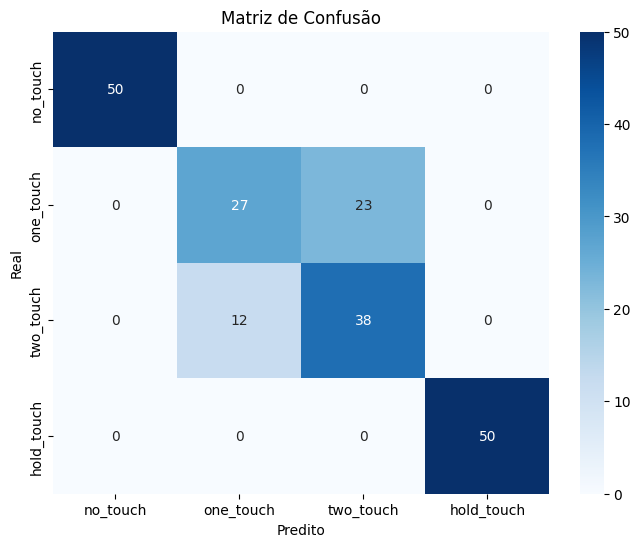

In [7]:
float_accuracy = evaluate(
    model_path="gesture_models/gesture_model.tflite",
    dataset_path="dataset.csv",
    scaler_path="gesture_models/scaler.pkl",
    show_plot=True
)

## 5) Validação do Modelo Quantizado (INT8)
Avalia se a aproximação matemática dos parâmetros para números inteiros afetou de forma expressiva o desempenho preditivo geral da rede.

Processando dados brutos do arquivo de validação...

Acurácia Final: 0.8250

              precision    recall  f1-score   support

    no_touch       1.00      1.00      1.00        50
   one_touch       0.69      0.54      0.61        50
   two_touch       0.62      0.76      0.68        50
  hold_touch       1.00      1.00      1.00        50

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


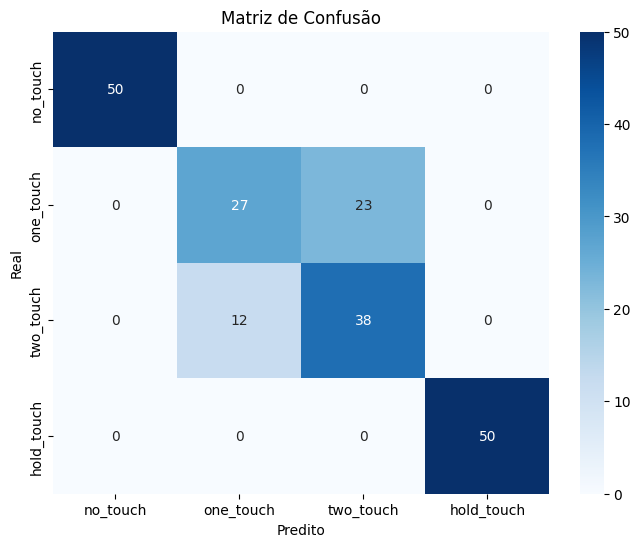

In [8]:
quantized_accuracy = evaluate(
    model_path="gesture_models/gesture_model_int8.tflite",
    dataset_path="dataset.csv",
    scaler_path="gesture_models/scaler.pkl",
    show_plot=True
)

## 6) Análise de Métricas e Compactação
Comparação lado a lado sobre os ganhos de memória física em disco versus a variação observada na acurácia analítica dos dois modelos criados.

In [9]:
comparison_rows = [
    ("Float model", float_accuracy),
    ("Quantized model", quantized_accuracy),
]

print(f"{'Model':<20} {'Accuracy':>12}")
print("-" * 34)

for model_name, accuracy_value in comparison_rows:
    print(f"{model_name:<20} {accuracy_value:>12.4f}")

accuracy_delta = quantized_accuracy - float_accuracy
print("\nDelta de Acurácia (quantized - float):")
print(f"Diferença real: {accuracy_delta:.4f}")

Model                    Accuracy
----------------------------------
Float model                0.8250
Quantized model            0.8250

Delta de Acurácia (quantized - float):
Diferença real: 0.0000


In [10]:
import os

float_size = os.path.getsize(
    "gesture_models/gesture_model.tflite"
) / 1024

int8_size = os.path.getsize(
    "gesture_models/gesture_model_int8.tflite"
) / 1024

print(f"\nTamanho do modelo Float32 : {float_size:.2f} KB")
print(f"Tamanho do modelo INT8    : {int8_size:.2f} KB")


Tamanho do modelo Float32 : 5.50 KB
Tamanho do modelo INT8    : 4.57 KB


### Exportação das Constantes para Código C/C++
Extração dos pesos de normalização obtidos pela classe `StandardScaler` do Scikit-Learn para portabilidade no firmware do ESP32.

In [11]:
import joblib
import numpy as np

try:
    scaler = joblib.load('gesture_models/scaler.pkl')
    meias = scaler.mean_
    desvios = scaler.scale_

    print("// Substitua no seu código C++ de Firmware:")
    print(f"const float SCALER_MEAN[8] = {{{', '.join([f'{x:.6f}f' for x in meias])}}};")
    print(f"const float SCALER_STD[8]  = {{{', '.join([f'{x:.6f}f' for x in desvios])}}};")

except Exception as e:
    print(f"Erro ao processar arquivo de parametrização: {e}")

// Substitua no seu código C++ de Firmware:
const float SCALER_MEAN[8] = {502.475000f, 842.380873f, 171.562790f, -44.640000f, 539.605000f, 885.501497f, 167.691599f, -38.225000f};
const float SCALER_STD[8]  = {335.876256f, 226.876794f, 124.674808f, 266.796890f, 337.427102f, 225.300457f, 122.622472f, 259.807937f};


### Conversão Binária (Hexdump)
Geração automatizada do arquivo `.cc` contendo a matriz de bytes brutos do modelo microcontrolado, pronto para ser embarcado no ecossistema da IDE do ESP32 (ESP-IDF ou Arduino).

In [12]:
!xxd -i gesture_models/gesture_model_int8.tflite > gesture_models/model_data.cc